In [1]:
from truckscenes import TruckScenes

In [2]:
trucksc = TruckScenes('v1.0-mini', '/home/cx/Downloads/man-truckscenes/', True)
trucksc.list_scenes()

Loading truckscenes tables for version v1.0-mini...
11 attribute,
18 calibrated_sensor,
27 category,
20090 ego_motion_cabin,
20089 ego_motion_chassis,
20116 ego_pose,
1094 instance,
400 sample,
25750 sample_annotation,
43556 sample_data,
10 scene,
18 sensor,
4 visibility,
Done loading in 0.626 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[23-08-24 09:09:31] scene-3195e3bfd1de4f9ba82f874790c7856c-15: length: 19.50s, #anns: 1500, desc: weather.overcast;area.highway;daytime.morning;seaso...
[23-08-26 08:13:49] scene-3f542f89ec5241b6a4e30ca743adcf34-29: length: 19.50s, #anns: 3291, desc: weather.overcast;area.highway;daytime.morning;seaso...
[23-09-17 08:19:52] scene-6be74229febb4aad9e7ae1a37217b231-4: length: 19.50s, #anns: 621, desc: weather.overcast;area.terminal;daytime.morning;seas...
[23-09-23 1

In [11]:
my_scene = trucksc.scene[3]
type(trucksc.scene)
for scene in trucksc.scene:
    # if 'terminal' in scene['description']:
    print(scene['description'])


weather.clear;area.terminal;daytime.noon;season.autumn;lighting.illuminated;structure.regular;construction.unchanged
weather.clear;area.highway;daytime.noon;season.autumn;lighting.dark;structure.overpass;construction.unchanged
weather.overcast;area.city;daytime.noon;season.winter;lighting.illuminated;structure.bridge;construction.unchanged
weather.overcast;area.highway;daytime.morning;season.summer;lighting.illuminated;structure.regular;construction.unchanged
weather.overcast;area.highway;daytime.morning;season.summer;lighting.illuminated;structure.regular;construction.roadworks
weather.overcast;area.terminal;daytime.morning;season.summer;lighting.illuminated;structure.regular;construction.unchanged
weather.clear;area.city;daytime.noon;season.winter;lighting.twilight;structure.regular;construction.unchanged
weather.snow;area.city;daytime.noon;season.autumn;lighting.illuminated;structure.regular;construction.unchanged
weather.rain;area.highway;daytime.noon;season.autumn;lighting.illumin

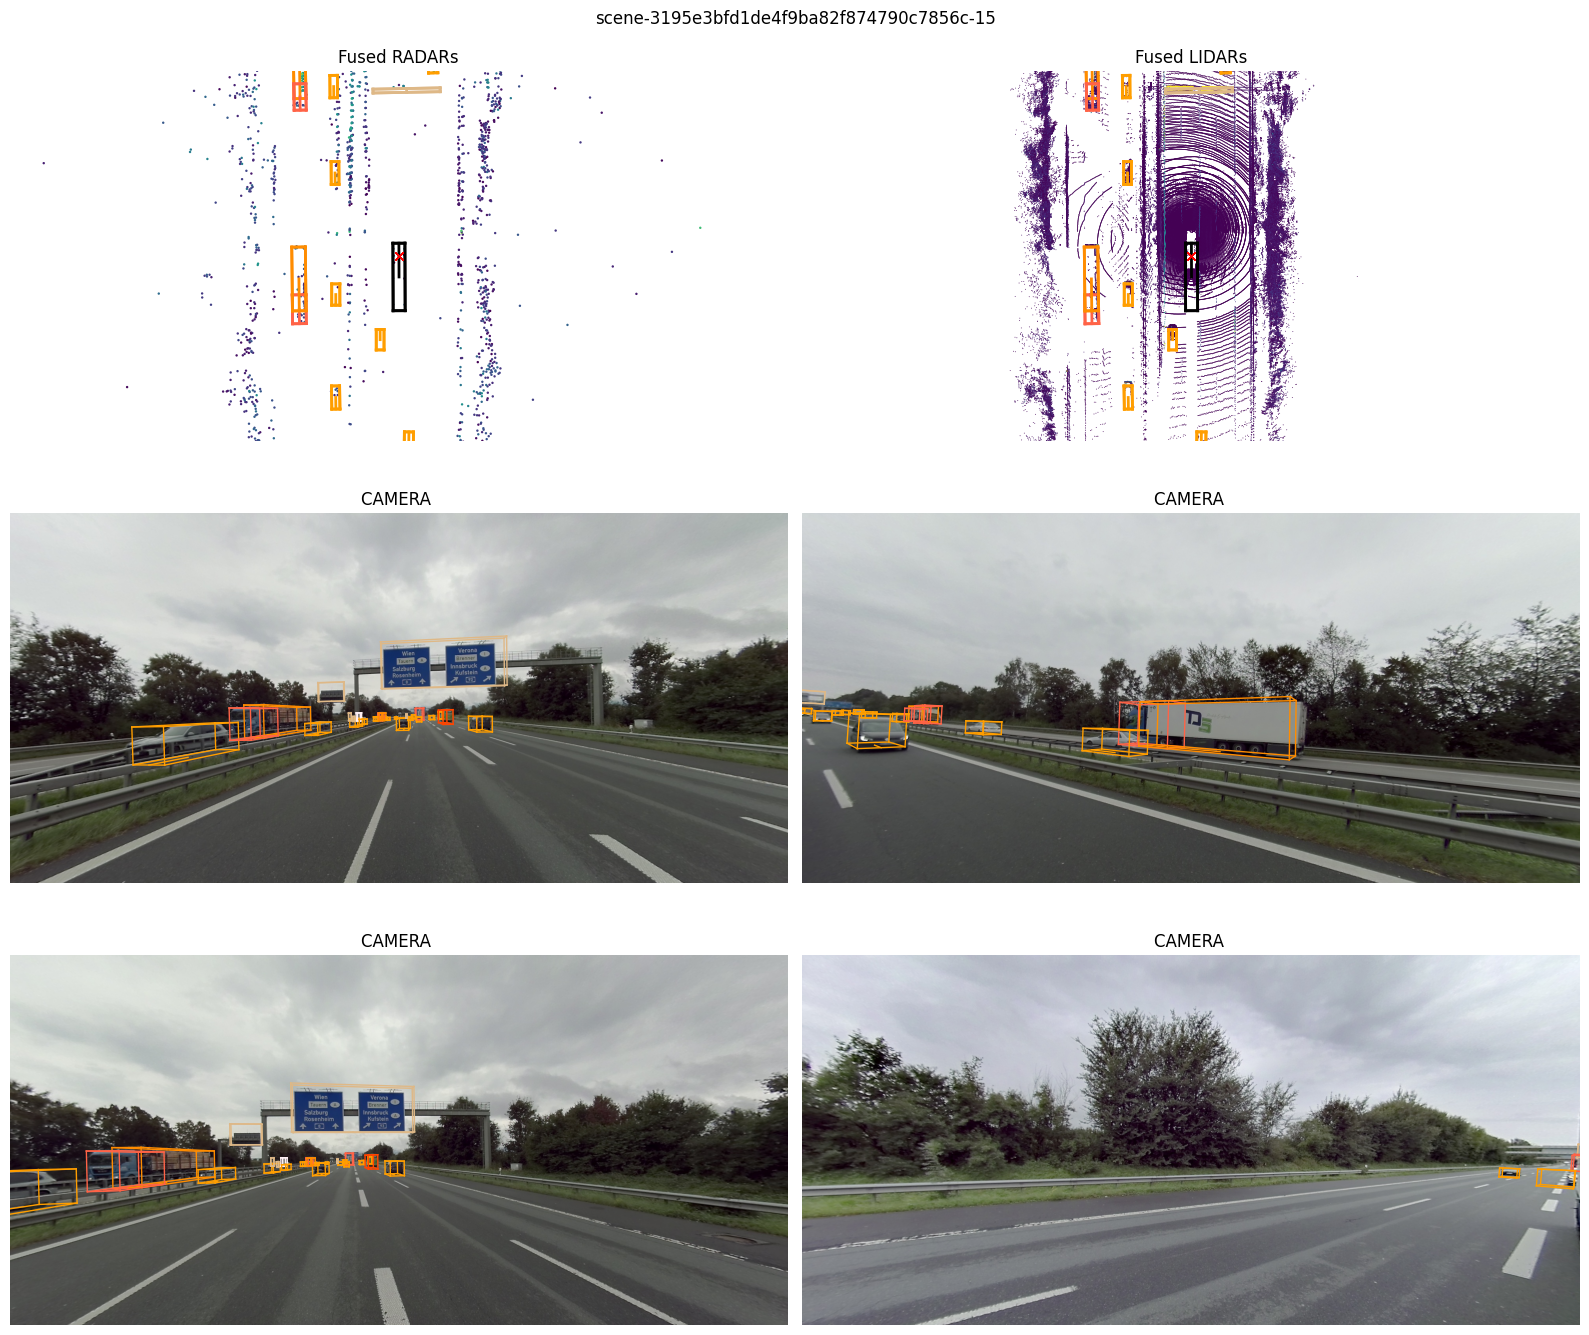

In [12]:
my_scene = trucksc.scene[3]
first_sample_token = my_scene['first_sample_token']
trucksc.render_sample(first_sample_token)

In [ ]:
my_sample = trucksc.get('sample', first_sample_token)
my_sample

In [ ]:
trucksc.list_sample(my_sample['token'])

In [ ]:
sensor = 'CAMERA_LEFT_FRONT'
cam_front_data = trucksc.get('sample_data', my_sample['data'][sensor])
cam_front_data
my_sample['data']

In [ ]:
trucksc.render_sample_data(cam_front_data['token'])

In [ ]:
my_annotation_token = my_sample['anns'][14]
my_annotation_metadata =  trucksc.get('sample_annotation', my_annotation_token)
my_annotation_metadata

In [ ]:
trucksc.render_annotation(my_annotation_token)

In [ ]:
my_sample

In [ ]:
all_scene = trucksc.scene
all_scene

In [ ]:
all_class = set()
show_list = []
for scene in all_scene:
    first_sample_token = scene['first_sample_token']
    last_sample_token = scene['first_sample_token']
    current_sample_token = first_sample_token
    while True:
        sample = trucksc.get('sample', current_sample_token)
        annos = sample['anns']
        for anno in annos:
            anno_data = trucksc.get('sample_annotation', anno)
            all_class.add(anno_data['category_name'])
            if 'movable_object.trafficcone' in anno_data['category_name']:
                show_list.append(anno)
            # print(anno_data)
        if current_sample_token == last_sample_token:
            break
        current_sample_token = sample['next']
print(all_class)
print(len(show_list))
# for show_data in show_list[:20]:
    # trucksc.render_annotation(show_data)
    # print(trucksc.get('sample_annotation', show_data)['category_name'], trucksc.get('sample_annotation', show_data)['size'])
        
# for show_data in show_list[20:40]:
    # trucksc.render_annotation(show_data)
    # print(trucksc.get('sample_annotation', show_data)['category_name'], trucksc.get('sample_annotation', show_data)['size']) 
    

In [ ]:
terminal_scene_list = []
for scene in trucksc.scene:
    # if 'terminal' in scene['description']:
        # print(scene['description'])
    terminal_scene_list.append(scene)
print(terminal_scene_list[0])
cls_total = {}
total_frame = 0
# 13  有堆高机
for index, terminal_scene in enumerate(terminal_scene_list):
    first_sample_token = terminal_scene['first_sample_token']
    last_sample_token = terminal_scene['first_sample_token']
    current_sample_token = first_sample_token


    if index == 312:
        my_scene_token = trucksc.field2token('scene', 'name', terminal_scene['name'])[0]
        trucksc.render_scene(my_scene_token)
        trucksc.render_sample(current_sample_token)
        sample = trucksc.get('sample', current_sample_token)
        annos = sample['anns']
        print(len(annos))
        for anno in annos:
            anno_data = trucksc.get('sample_annotation', anno)
            print(anno_data['category_name'])
            # if 'trailer' in anno_data['category_name']:
            #     trucksc.render_annotation(anno)
        break
    while True:
        if current_sample_token == '':
            break
        if (current_sample_token == last_sample_token and current_sample_token != first_sample_token):
            break
        total_frame += 1
        sample = trucksc.get('sample', current_sample_token)
        annos = sample['anns']
        for anno in annos:
            anno_data = trucksc.get('sample_annotation', anno)
            cls_name = anno_data['category_name']
            if cls_name not in cls_total:
                cls_total[cls_name] = 0
            else:
                cls_total[cls_name] += 1
        current_sample_token = sample['next']
        
print(total_frame, cls_total)
           

